# HMDA Data Analysis - Kansas State

This notebook analyzes HMDA (Home Mortgage Disclosure Act) data from Kansas state to understand loan application outcomes, including total records, valid entries, approved loans, and denied loans.

## Objective
- Count total number of records in the dataset
- Count records with valid action_taken values
- Count approved loan applications
- Count denied loan applications
- Calculate approval and denial rates

## 1. Import Required Libraries

Import necessary libraries for data manipulation, analysis, and visualization.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load HMDA Data

Load the Kansas state HMDA data from the CSV file and display basic information about the dataset.

In [2]:
# Load the HMDA data from Kansas state CSV file
data_path = Path("../data/actual/state_KS.csv")

# Check if file exists
if data_path.exists():
    print(f"Loading data from: {data_path}")
    df = pd.read_csv(data_path)
    print(f"✅ Data loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
else:
    print(f"❌ File not found: {data_path}")
    print("Please check the file path.")

Loading data from: ../data/actual/state_KS.csv
✅ Data loaded successfully!
📊 Dataset shape: (94530, 99)
✅ Data loaded successfully!
📊 Dataset shape: (94530, 99)


## 3. Data Overview and Validation

Examine the dataset structure, column names, data types, and check for missing values in the action_taken column.

In [3]:
# Display basic information about the dataset
print("=== Dataset Overview ===")
print(f"📊 Total rows: {len(df):,}")
print(f"📊 Total columns: {len(df.columns)}")
print()

# Display first few rows
print("=== First 5 rows ===")
print(df.head())
print()

# Check data types and missing values
print("=== Data Types and Missing Values ===")
print(df.info())
print()

# Focus on action_taken column
print("=== Action Taken Column Analysis ===")
print(f"Column name: action_taken")
print(f"Data type: {df['action_taken'].dtype}")
print(f"Missing values: {df['action_taken'].isnull().sum():,}")
print(f"Valid values: {df['action_taken'].notnull().sum():,}")
print()

# Show unique values in action_taken column
print("=== Unique Values in action_taken ===")
action_taken_counts = df['action_taken'].value_counts().sort_index()
print(action_taken_counts)

=== Dataset Overview ===
📊 Total rows: 94,530
📊 Total columns: 99

=== First 5 rows ===
   activity_year                   lei  derived_msa-md state_code  \
0           2024  5493000F6NFDOVVZP043           48620         KS   
1           2024  5493000F6NFDOVVZP043           28140         KS   
2           2024  549300D5WZYDJFZQJ463           99999         KS   
3           2024  549300D5WZYDJFZQJ463           99999         KS   
4           2024  549300D5WZYDJFZQJ463           99999         KS   

   county_code  census_tract conforming_loan_limit derived_loan_product_type  \
0      20015.0  2.001502e+10                     C   Conventional:First Lien   
1      20091.0  2.009105e+10                     C   Conventional:First Lien   
2          NaN           NaN                     C   Conventional:First Lien   
3          NaN           NaN                     C   Conventional:First Lien   
4          NaN           NaN                     C   Conventional:First Lien   

              de

## 4. Count Valid Action Taken Records

Filter and count records that have valid (non-null) values in the action_taken column.

In [4]:
# Count total records
total_records = len(df)
print(f"📊 Total records in dataset: {total_records:,}")

# Count records with valid action_taken values (non-null)
valid_action_taken = df['action_taken'].notnull().sum()
print(f"✅ Records with valid action_taken: {valid_action_taken:,}")

# Count records with missing action_taken values
missing_action_taken = df['action_taken'].isnull().sum()
print(f"❌ Records with missing action_taken: {missing_action_taken:,}")

# Calculate percentage of valid records
valid_percentage = (valid_action_taken / total_records) * 100
print(f"📈 Percentage of valid action_taken records: {valid_percentage:.2f}%")

📊 Total records in dataset: 94,530
✅ Records with valid action_taken: 94,530
❌ Records with missing action_taken: 0
📈 Percentage of valid action_taken records: 100.00%


## 5. Count Approved Loans

Filter and count records where action_taken indicates approved loans.

**HMDA Action Taken Codes:**
- **1**: Loan originated (APPROVED)
- **2**: Application approved but not accepted (APPROVED)
- **6**: Purchased loan (APPROVED)
- **8**: Preapproval request approved but not accepted (APPROVED)

In [5]:
# Define approved loan action codes
approved_codes = [1, 2, 6, 8]

# Count approved loans
approved_loans = df[df['action_taken'].isin(approved_codes)]
approved_count = len(approved_loans)

print(f"✅ Total approved loans: {approved_count:,}")
print()

# Breakdown by approval type
print("=== Breakdown by Approval Type ===")
for code in approved_codes:
    count = len(df[df['action_taken'] == code])
    if count > 0:
        if code == 1:
            description = "Loan originated"
        elif code == 2:
            description = "Application approved but not accepted"
        elif code == 6:
            description = "Purchased loan"
        elif code == 8:
            description = "Preapproval approved but not accepted"
        
        print(f"Code {code} ({description}): {count:,}")

# Calculate approval rate
if valid_action_taken > 0:
    approval_rate = (approved_count / valid_action_taken) * 100
    print(f"\n📈 Approval rate: {approval_rate:.2f}%")

✅ Total approved loans: 67,195

=== Breakdown by Approval Type ===
Code 1 (Loan originated): 53,667
Code 2 (Application approved but not accepted): 3,066
Code 6 (Purchased loan): 10,025
Code 8 (Preapproval approved but not accepted): 437

📈 Approval rate: 71.08%


## 6. Count Denied Loans

Filter and count records where action_taken indicates denied loans.

**HMDA Denial Codes:**
- **3**: Application denied
- **7**: Preapproval request denied

In [6]:
# Define denied loan action codes
denied_codes = [3, 7]

# Count denied loans
denied_loans = df[df['action_taken'].isin(denied_codes)]
denied_count = len(denied_loans)

print(f"❌ Total denied loans: {denied_count:,}")
print()

# Breakdown by denial type
print("=== Breakdown by Denial Type ===")
for code in denied_codes:
    count = len(df[df['action_taken'] == code])
    if count > 0:
        if code == 3:
            description = "Application denied"
        elif code == 7:
            description = "Preapproval request denied"
        
        print(f"Code {code} ({description}): {count:,}")

# Calculate denial rate
if valid_action_taken > 0:
    denial_rate = (denied_count / valid_action_taken) * 100
    print(f"\n📈 Denial rate: {denial_rate:.2f}%")

❌ Total denied loans: 13,824

=== Breakdown by Denial Type ===
Code 3 (Application denied): 13,474
Code 7 (Preapproval request denied): 350

📈 Denial rate: 14.62%


## 7. Generate Summary Statistics

Create a comprehensive summary table showing all key metrics and visualize the loan outcome distribution.

In [7]:
# Calculate other categories (withdrawn, incomplete, etc.)
other_count = valid_action_taken - approved_count - denied_count

# Create summary statistics table
summary_data = {
    'Metric': [
        'Total Records',
        'Valid Action Taken Records',
        'Missing Action Taken Records',
        'Approved Loans',
        'Denied Loans',
        'Other Actions',
        'Approval Rate (%)',
        'Denial Rate (%)',
        'Other Rate (%)'
    ],
    'Count': [
        f"{total_records:,}",
        f"{valid_action_taken:,}",
        f"{missing_action_taken:,}",
        f"{approved_count:,}",
        f"{denied_count:,}",
        f"{other_count:,}",
        f"{(approved_count/valid_action_taken*100):.2f}%" if valid_action_taken > 0 else "N/A",
        f"{(denied_count/valid_action_taken*100):.2f}%" if valid_action_taken > 0 else "N/A",
        f"{(other_count/valid_action_taken*100):.2f}%" if valid_action_taken > 0 else "N/A"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=" * 50)
print("📊 HMDA KANSAS STATE - SUMMARY STATISTICS")
print("=" * 50)
print(summary_df.to_string(index=False))
print("=" * 50)

📊 HMDA KANSAS STATE - SUMMARY STATISTICS
                      Metric  Count
               Total Records 94,530
  Valid Action Taken Records 94,530
Missing Action Taken Records      0
              Approved Loans 67,195
                Denied Loans 13,824
               Other Actions 13,511
           Approval Rate (%) 71.08%
             Denial Rate (%) 14.62%
              Other Rate (%) 14.29%


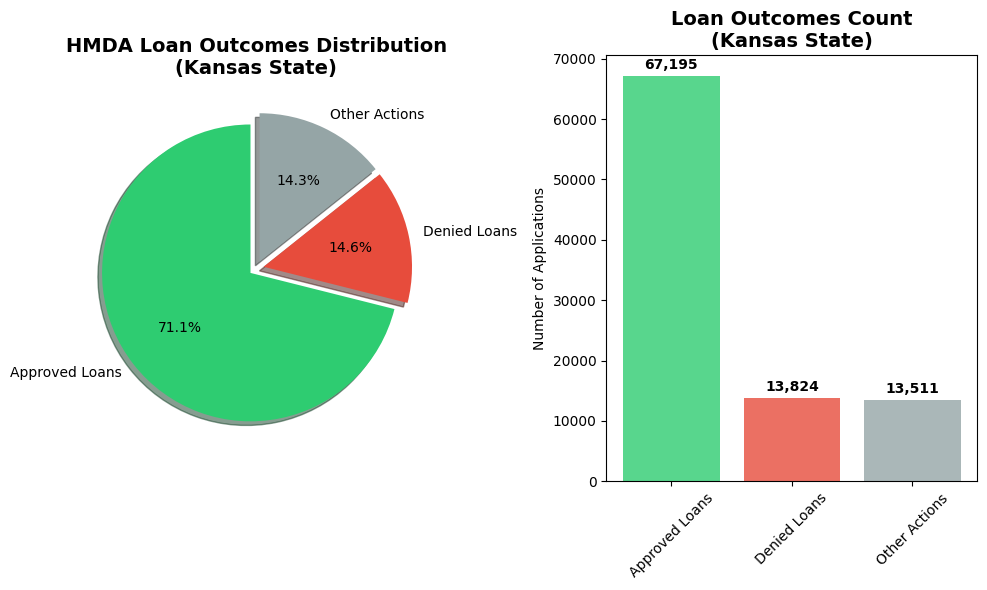


✅ Analysis complete! The notebook has analyzed 94,530 HMDA records from Kansas state.
📈 Key findings: 67,195 approved loans, 13,824 denied loans out of 94,530 valid applications.


In [8]:
# Create a pie chart to visualize loan outcomes
plt.figure(figsize=(10, 6))

# Prepare data for visualization
labels = ['Approved Loans', 'Denied Loans', 'Other Actions']
sizes = [approved_count, denied_count, other_count]
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
explode = (0.05, 0.05, 0.05)  # slightly separate each slice

plt.subplot(1, 2, 1)
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.title('HMDA Loan Outcomes Distribution\n(Kansas State)', fontsize=14, fontweight='bold')

# Create a bar chart
plt.subplot(1, 2, 2)
bars = plt.bar(labels, sizes, color=colors, alpha=0.8)
plt.title('Loan Outcomes Count\n(Kansas State)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sizes)*0.01,
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Analysis complete! The notebook has analyzed {total_records:,} HMDA records from Kansas state.")
print(f"📈 Key findings: {approved_count:,} approved loans, {denied_count:,} denied loans out of {valid_action_taken:,} valid applications.")